# Validating Models on Climate and Environmental Data

Nearly every machine learning tutorial evaluates a model the same way: shuffle the data,
hold out a random 20%, and report the score on that held-out set. For the toy datasets in
those tutorials, that is the right thing to do.

For climate and environmental data, it is usually **wrong**, and it fails in a specific
direction — it makes your model look *better* than it is. This page covers three reasons why:

- **Spatial autocorrelation** — nearby grid cells are nearly duplicates, so a random split
  puts near-copies of your test data into the training set
- **Temporal autocorrelation** — the same problem along the time axis, plus the risk of
  training on the future to predict the past
- **Extrapolation** — climate applications ask models to make predictions outside the range
  of conditions they were trained on, which is where many models fail silently

The unifying idea is that the standard random split assumes your samples are
**independent and identically distributed (i.i.d.)**. Geophysical data are almost never
i.i.d. Everything below follows from that one violated assumption.

## First: always compare against a baseline

Before asking whether a model is *good*, ask what it is being compared *to*. A model that
explains 85% of the variance sounds impressive until you learn that simply predicting
yesterday's value explains 84%.

Two baselines are standard in climate work:

- **Climatology** — always predict the long-term mean (for that day of year, that location)
- **Persistence** — always predict the most recent observed value

A useful model has to beat both. Reporting a skill score without a baseline is not a result.

climatology  R^2 = 0.872
persistence  R^2 = 0.956


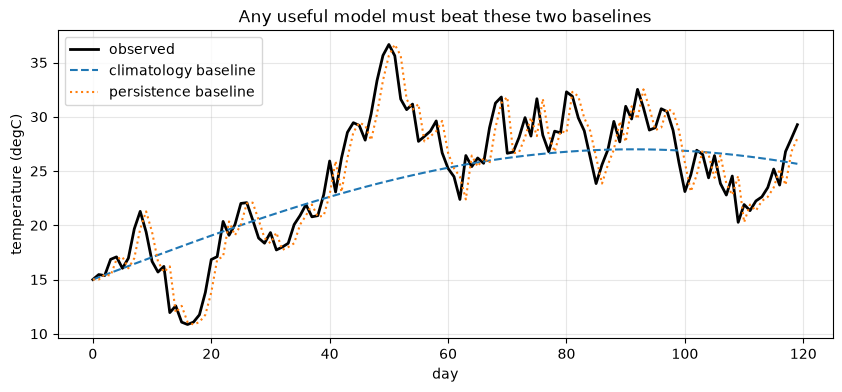

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

rng = np.random.default_rng(0)

# A synthetic daily temperature series: seasonal cycle + persistent weather anomaly.
n_days = 730
day = np.arange(n_days)
seasonal = 12 * np.sin(2 * np.pi * day / 365.25)

# AR(1) weather anomaly -- today's anomaly is highly correlated with yesterday's.
anom = np.zeros(n_days)
for t in range(1, n_days):
    anom[t] = 0.85 * anom[t - 1] + rng.normal(0, 2.0)

temp = 15 + seasonal + anom

clim = 15 + seasonal                 # climatology: seasonal cycle only
persist = np.concatenate([[temp[0]], temp[:-1]])   # persistence: yesterday's value

print(f"climatology  R^2 = {r2_score(temp, clim):.3f}")
print(f"persistence  R^2 = {r2_score(temp, persist):.3f}")

plt.figure(figsize=(10, 4))
plt.plot(day[:120], temp[:120], "k-", lw=2, label="observed")
plt.plot(day[:120], clim[:120], "--", label="climatology baseline")
plt.plot(day[:120], persist[:120], ":", label="persistence baseline")
plt.xlabel("day")
plt.ylabel("temperature (degC)")
plt.title("Any useful model must beat these two baselines")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Persistence is a strong baseline precisely *because* the anomaly is autocorrelated — and that
same autocorrelation is what will corrupt our cross-validation below.

## Spatial autocorrelation breaks random cross-validation

Consider predicting some environmental variable across a spatial grid from a set of
predictor fields. Neighboring grid cells have nearly identical predictor values *and*
nearly identical target values.

Now shuffle and split randomly. Every test cell has several of its immediate neighbors
sitting in the training set. The model does not need to learn the underlying relationship —
it can succeed by effectively looking up the answer from a neighbor. The test score measures
**how smooth the field is**, not how well the model generalizes.

Let's build a field where we know the truth, so we can measure the size of the illusion.

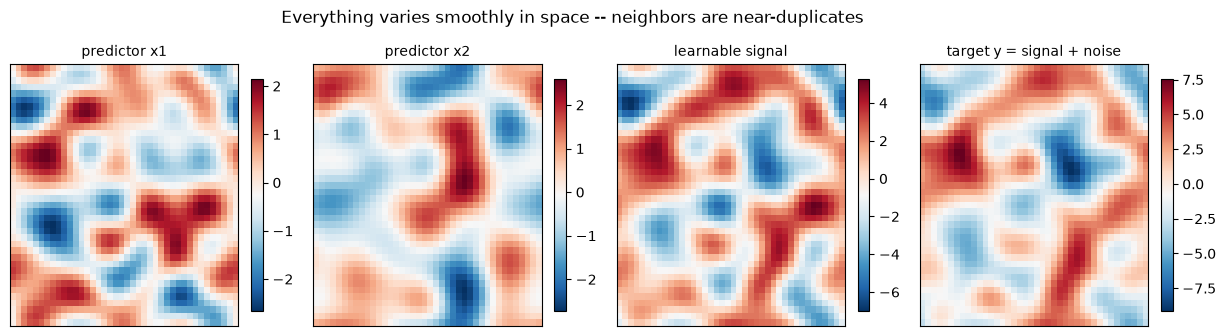

In [2]:
def smooth_field(rng, LON, LAT, k=4):
    # Random field that varies smoothly in space (a sum of low-frequency modes).
    f = np.zeros_like(LON)
    for i in range(1, k + 1):
        for j in range(1, k + 1):
            amp = rng.normal() / (i * j)
            p1, p2 = rng.uniform(0, 2 * np.pi, 2)
            f += amp * np.sin(2 * np.pi * i * LON + p1) * np.sin(2 * np.pi * j * LAT + p2)
    return (f - f.mean()) / f.std()


n = 40
grid = np.linspace(0, 1, n)
LON, LAT = np.meshgrid(grid, grid)
rng = np.random.default_rng(42)

x1 = smooth_field(rng, LON, LAT)
x2 = smooth_field(rng, LON, LAT)

# The learnable signal, plus spatially-correlated "noise" that is NOT a function of
# the predictors. No model can legitimately predict the noise term.
signal = 2.0 * x1 - 1.5 * x2
noise = 1.2 * smooth_field(rng, LON, LAT, k=6)
y_field = signal + noise

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, field, name in zip(axes, [x1, x2, signal, y_field],
                           ["predictor x1", "predictor x2",
                            "learnable signal", "target y = signal + noise"]):
    im = ax.pcolormesh(LON, LAT, field, cmap="RdBu_r", shading="auto")
    ax.set_title(name, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Everything varies smoothly in space -- neighbors are near-duplicates", y=1.04)
plt.show()

Now we fit the same model two ways. The only difference is **how the folds are chosen**.

- **Random K-fold** — shuffle all 1600 cells, split into 5 folds
- **Spatial block K-fold** — cut the map into contiguous blocks and hold out whole blocks,
  so no test cell has a neighbor in the training set

random K-fold CV      R^2 = 0.957  (+/- 0.004)
spatial block CV      R^2 = 0.785  (+/- 0.032)
true achievable ceiling R^2 = 0.852


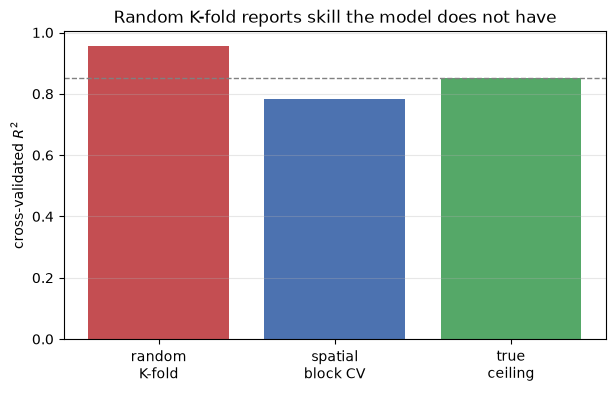

In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_val_score

# Features include latitude and longitude, which is common practice in geospatial ML.
X = np.column_stack([x1.ravel(), x2.ravel(), LAT.ravel(), LON.ravel()])
y = y_field.ravel()

# Spatial blocks: 4x4 = 16 contiguous tiles, assigned to 4 cross-validation groups.
block_r = (np.arange(n) // (n // 4))
BR, BC = np.meshgrid(block_r, block_r, indexing="ij")
blocks = (BR * 4 + BC).ravel()
groups = blocks % 4

model = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)

random_cv = cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=0),
                            scoring="r2")
block_cv = cross_val_score(model, X, y, cv=GroupKFold(4), groups=groups, scoring="r2")

# The honest ceiling: even a perfect model cannot predict the unlearnable noise term.
ceiling = r2_score(y, signal.ravel())

print(f"random K-fold CV      R^2 = {random_cv.mean():.3f}  (+/- {random_cv.std():.3f})")
print(f"spatial block CV      R^2 = {block_cv.mean():.3f}  (+/- {block_cv.std():.3f})")
print(f"true achievable ceiling R^2 = {ceiling:.3f}")

plt.figure(figsize=(7, 4))
bars = plt.bar(["random\nK-fold", "spatial\nblock CV", "true\nceiling"],
               [random_cv.mean(), block_cv.mean(), ceiling],
               color=["#c44e52", "#4c72b0", "#55a868"])
plt.axhline(ceiling, color="gray", ls="--", lw=1)
plt.ylabel("cross-validated $R^2$")
plt.title("Random K-fold reports skill the model does not have")
plt.grid(axis="y", alpha=0.3)
plt.show()

The random split reports a score **above the true ceiling** — it claims the model predicted
variance that is mathematically unpredictable from the features. That is the signature of
leakage. The block CV score is close to the ceiling, which is the honest answer.

Two practical consequences:

- Including **latitude and longitude as features** makes this much worse. It lets the model
  memorize position, which is pure lookup rather than a physical relationship. If you use
  coordinates as features, blocked validation is mandatory, not optional.
- The gap widens as the field gets smoother. For a highly autocorrelated variable, random CV
  can be off by a large margin.

In real work, use `GroupKFold` with contiguous spatial blocks, or hold out entire regions,
basins, or stations. The rule: **the test set should be as far from the training set as your
intended application is.** If you plan to apply the model to a new region, validate on a
held-out region.

## Temporal autocorrelation and forward-chaining

The same argument applies along the time axis, with an extra problem: a random split trains
on the future to predict the past. That is not a scenario your model will ever face
operationally, so any score it produces is meaningless.

The correct approach is **forward chaining** (`TimeSeriesSplit`): always train on a past
window and test on the window immediately after it.

random K-fold (trains on the future) R^2 = 0.436
forward-chaining TimeSeriesSplit     R^2 = -0.362
persistence baseline                 R^2 = 0.935


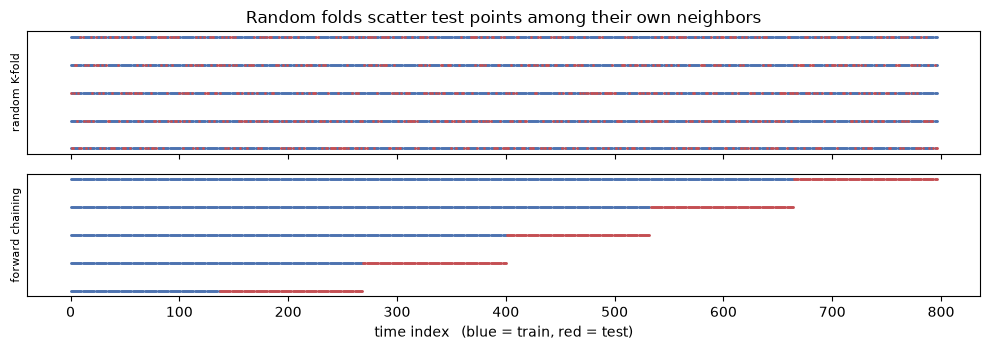

In [4]:
from sklearn.model_selection import TimeSeriesSplit

T = 800
rng = np.random.default_rng(7)

# An observable driver, autocorrelated in time.
drive = np.zeros(T)
for t in range(1, T):
    drive[t] = 0.9 * drive[t - 1] + rng.normal(0, 1.0)

# A slow, unobserved mode (think a decadal oscillation we did not measure). It is
# smooth in time but NOT a function of the driver, so it is unlearnable from X.
raw = rng.normal(0, 1, T + 120)
wander = np.convolve(raw, np.ones(121) / 121, mode="same")[:T]
wander = (wander - wander.mean()) / wander.std()

resp = 0.7 * drive + 0.5 * np.roll(drive, 1) + 2.5 * wander

Xt = np.column_stack([drive, np.roll(drive, 1), np.roll(drive, 2)])[3:]
yt = resp[3:]

mdl = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
rand_scores = cross_val_score(mdl, Xt, yt, cv=KFold(5, shuffle=True, random_state=0),
                              scoring="r2")
fwd_scores = cross_val_score(mdl, Xt, yt, cv=TimeSeriesSplit(5), scoring="r2")
persist_r2 = r2_score(yt[1:], yt[:-1])

print(f"random K-fold (trains on the future) R^2 = {rand_scores.mean():.3f}")
print(f"forward-chaining TimeSeriesSplit     R^2 = {fwd_scores.mean():.3f}")
print(f"persistence baseline                 R^2 = {persist_r2:.3f}")

# Show how the two schemes lay out train/test along the time axis.
fig, axes = plt.subplots(2, 1, figsize=(10, 3.6), sharex=True)
for ax, cv, name in zip(axes, [KFold(5, shuffle=True, random_state=0), TimeSeriesSplit(5)],
                        ["random K-fold", "forward chaining"]):
    for k, (tr, te) in enumerate(cv.split(Xt)):
        ax.scatter(tr, np.full_like(tr, k), s=1, c="#4c72b0")
        ax.scatter(te, np.full_like(te, k), s=1, c="#c44e52")
    ax.set_ylabel(name, fontsize=8)
    ax.set_yticks([])
axes[1].set_xlabel("time index   (blue = train, red = test)")
axes[0].set_title("Random folds scatter test points among their own neighbors")
plt.tight_layout()
plt.show()

Read those three numbers together, because the story they tell is worse than a simple
inflation of skill.

Random K-fold reports a modest but respectable score — around 0.4. It looks like a model that
works, just not spectacularly. Forward chaining reports a **negative** $R^2$, meaning the model
performs *worse than predicting the mean* on genuinely future data. And persistence, the
do-nothing baseline, scores above 0.9.

So the honest conclusion is that this model is useless, and the standard random split not only
hid that, it produced a number plausible enough that nobody would think to question it. The
model was scoring by recognizing the slow unobserved mode from its temporal neighbors in the
training set — information that does not exist when you forecast forward.

The lower panel of the figure shows why: random folds interleave test points among their own
neighbors, while forward chaining keeps every test block strictly after its training data.

## Extrapolation: the failure mode specific to climate

This one matters more than the other two, and it is the least discussed.

Climate applications routinely ask a model trained on historical conditions to make
predictions about conditions that have never been observed — a warmer mean state, a higher
CO2 concentration, a more extreme event than any in the record. This is **extrapolation**,
and different model families behave very differently when asked to do it.

Tree-based models — random forests, gradient boosting — **cannot extrapolate at all**. A tree
predicts by averaging the training samples in a leaf, so its output can never exceed the
range of targets it was trained on. Beyond the edge of the training data, the prediction
goes flat.

in-sample (train) R^2   linear = 0.972   RF = 0.994
extrapolated (test) R^2 linear = 0.941   RF = -3.388


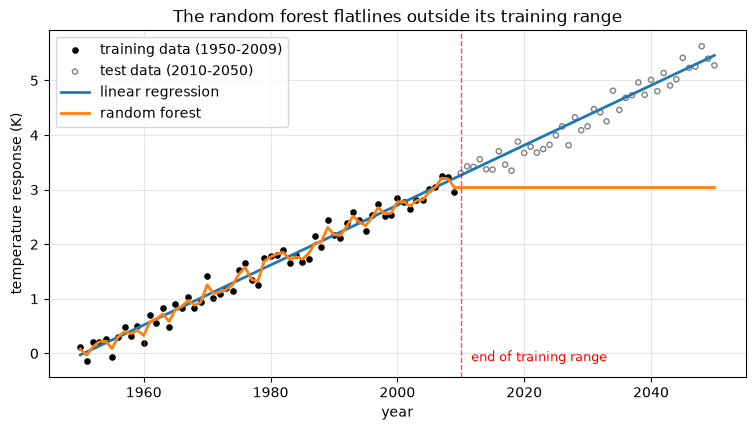

In [5]:
from sklearn.linear_model import LinearRegression

# A warming trend: train on the cooler early period, test on the warmer later period.
years = np.arange(1950, 2051)
forcing = np.linspace(0, 3.0, len(years))
temp_resp = 1.8 * forcing + rng.normal(0, 0.15, len(years))

split = 60   # train on 1950-2009, test on 2010-2050
Xtr, ytr = forcing[:split].reshape(-1, 1), temp_resp[:split]
Xte, yte = forcing[split:].reshape(-1, 1), temp_resp[split:]

lin = LinearRegression().fit(Xtr, ytr)
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(Xtr, ytr)

print(f"in-sample (train) R^2   linear = {lin.score(Xtr, ytr):.3f}   RF = {rf.score(Xtr, ytr):.3f}")
print(f"extrapolated (test) R^2 linear = {lin.score(Xte, yte):.3f}   RF = {rf.score(Xte, yte):.3f}")

plt.figure(figsize=(9, 4.5))
plt.scatter(years[:split], ytr, s=14, c="k", label="training data (1950-2009)")
plt.scatter(years[split:], yte, s=14, facecolors="none", edgecolors="gray",
            label="test data (2010-2050)")
plt.plot(years, lin.predict(forcing.reshape(-1, 1)), lw=2, label="linear regression")
plt.plot(years, rf.predict(forcing.reshape(-1, 1)), lw=2, label="random forest")
plt.axvline(years[split], color="red", ls="--", lw=1, alpha=0.7)
plt.text(years[split] + 1, ytr.min(), " end of training range", color="red", fontsize=9)
plt.xlabel("year")
plt.ylabel("temperature response (K)")
plt.title("The random forest flatlines outside its training range")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.show()

Both models fit the training period well. Only one of them is usable for projection.

This is not a flaw to be fixed by tuning — it is structural. It means the choice of model
family in climate work is partly a question about **what you will ask the model to do**:

- Interpolating within observed conditions (gap-filling, retrievals, detection) — tree
  ensembles are excellent
- Projecting beyond observed conditions (future scenarios, unobserved extremes) — you need a
  model with an appropriate functional form, physical constraints, or an explicit warning
  when inputs fall outside the training distribution

A practical habit: always record the range of your training inputs, and check at prediction
time whether new inputs fall outside it. A model should refuse, or at minimum flag, inputs it
has no basis for.

## Checklist

Before reporting a result on environmental data:

1. **What is the baseline?** Climatology and persistence, at minimum. Report them alongside
   your model.
2. **Does the validation split match the application?** New region → hold out regions. Future
   period → hold out the future. New station → hold out stations.
3. **Is there spatial or temporal structure in the data?** If so, random K-fold is
   inappropriate. Use `GroupKFold` with spatial blocks or `TimeSeriesSplit`.
4. **Did any preprocessing see the test set?** Scalers, imputers, and feature selection must
   be fit inside the training fold — use a `Pipeline` so cross-validation handles this for you.
5. **Will the model be asked to extrapolate?** If yes, check whether the model family can,
   and check the input range at prediction time.
6. **Is the reported skill plausible?** A score that seems too good usually is. Leakage is far
   more common than a breakthrough.

Points 1 and 6 are worth internalizing: in this field, an unexpectedly high score is a prompt
to go looking for a bug, not to celebrate.